In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

In [2]:
X_test = pd.read_csv("../data/processed/X_test.csv")

y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
saved_models = {

    "Logistic Regression":
        joblib.load("../models/logistic_regression.pkl"),

    "Decision Tree":
        joblib.load("../models/decision_tree.pkl"),

    "Random Forest":
        joblib.load("../models/random_forest.pkl"),

    "Gradient Boosting":
        joblib.load("../models/gradient_boosting.pkl"),

    "XGBoost":
        joblib.load("../models/xgboost.pkl")

}

In [4]:
evaluation_results = []

In [5]:
for name, model in saved_models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    evaluation_results.append({

        "Model":name,

        "Accuracy":
            accuracy_score(y_test,y_pred),

        "Precision":
            precision_score(y_test,y_pred),

        "Recall":
            recall_score(y_test,y_pred),

        "F1 Score":
            f1_score(y_test,y_pred),

        "ROC-AUC":
            roc_auc_score(y_test,y_prob)

    })

In [6]:
comparison_df = pd.DataFrame(
    evaluation_results
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.821150,0.685015,0.600536,0.640000,0.862123
1,Decision Tree,0.715401,0.464103,0.485255,0.474443,0.642908
2,Random Forest,0.797019,0.662921,0.474531,0.553125,0.834786
3,Gradient Boosting,0.807665,0.674658,0.528150,0.592481,0.859582
4,XGBoost,0.788502,0.623762,0.506702,0.559172,0.843164


In [7]:
comparison_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

In [8]:
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.821150,0.685015,0.600536,0.640000,0.862123
3,Gradient Boosting,0.807665,0.674658,0.528150,0.592481,0.859582
4,XGBoost,0.788502,0.623762,0.506702,0.559172,0.843164
2,Random Forest,0.797019,0.662921,0.474531,0.553125,0.834786
1,Decision Tree,0.715401,0.464103,0.485255,0.474443,0.642908


In [9]:
comparison_df.to_csv(
    "../reports/evaluation/model_comparison.csv",
    index=False
)

In [10]:
best_model = joblib.load(
    "../models/best_model.pkl"
)

In [11]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

In [12]:
accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

auc = roc_auc_score(y_test,y_prob)

In [13]:
metrics_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Score":[
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]

})

metrics_df

,Metric,Score
0,Accuracy,0.804116
1,Precision,0.666667
2,Recall,0.520107
3,F1 Score,0.584337
4,ROC-AUC,0.860604


In [14]:
metrics_df.to_csv(
    "../reports/evaluation/best_model_metrics.csv",
    index=False
)

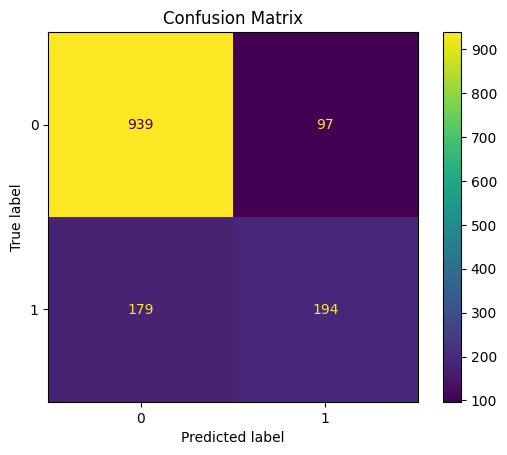

In [15]:
cm = confusion_matrix(
    y_test,
    y_pred
)

ConfusionMatrixDisplay(cm).plot()

plt.title("Confusion Matrix")

plt.savefig(
    "../reports/figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
report = classification_report(
    y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.52      0.58       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [17]:
with open(
    "../reports/evaluation/classification_report.txt",
    "w"
) as f:

    f.write(report)

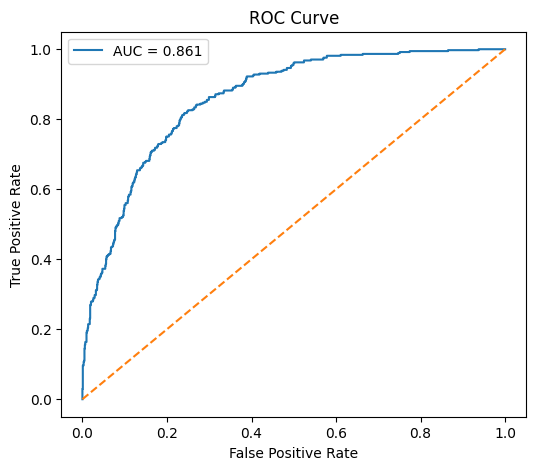

In [18]:
fpr,tpr,_ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig(
    "../reports/figures/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()